In [1]:
!pip install "transformer-lens<4.0"

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.9 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12526 sha256=9499c8475ee8b9c84800d1702337a87452164b2a4111289e18f12263b2b6ad0b
  Stored in directory: /root/.cache/pip/wheels/f6/6e/1a/710143d0e50e827ae5b60a47a6d43d715cf1c6e35881a05530
Successfully built transformers-stream-generator


In [2]:
# 1. Load small model (using a smaller model like GPT-2 small for demonstration)

import torch
import torch.nn.functional as F
from transformer_lens import HookedTransformer
device = "cuda" if torch.cuda.is_available() else "cpu"
model = HookedTransformer.from_pretrained("gpt2-small", device=device)


/tmp/ipykernel_1356/3151803557.py:7: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained("gpt2-small", device=device)


Loaded pretrained model gpt2-small into HookedTransformer


**Record the clean cache**

In [3]:
clean_prompt = "My dog is a good"
clean_tokens = model.to_tokens(clean_prompt)
logits, clean_cache = model.run_with_cache(clean_prompt)

# answer token id
answer_token = model.to_single_token(' dog')
clean_logit = logits[0, -1, answer_token].item()

print(f"Clean Logits: {clean_logit}")

Clean Logits: 14.100128173828125


**Record the corrupted Cache**

In [4]:
corrupted_prompt = "My dog is a good"

corrupted_tokens = model.to_tokens(corrupted_prompt)
corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_prompt)

# answer token id
corrupted_answer = model.to_single_token(' friend')
corrupted_logit = corrupted_logits[0, -1, corrupted_answer].item()

print(f"Corrupted Logits: {corrupted_logit}")

Corrupted Logits: 14.00554084777832


In [5]:
def patch_resid_pre(corrupted_resid, hook, clean_cache):
    return clean_cache[hook.name]

**Patching the layer 3**

In [6]:
layer = 3

patched_logits = model.run_with_hooks(
    corrupted_tokens,
    fwd_hooks=[
        (
            f"blocks.{layer}.hook_resid_pre",
            lambda resid, hook: patch_resid_pre(
                resid,
                hook,
                clean_cache
            )
        )
    ]
)

In [7]:
patched_logit = patched_logits[0, -1, answer_token].item()
print(f"Patched Logits: {patched_logit}")

Patched Logits: 14.100128173828125


In [27]:
import torch

# 1. Get the residual stream activation at layer 3 (pre-residual) for the final token
# The shape is [batch, position, d_model]
ly = 3
resid_act = clean_cache[f"blocks.{ly}.hook_resid_pre"][0, -1, :]

# 2. Apply the final LayerNorm (ln_final) to match the model's final output pipeline
normalized_act = model.ln_final(resid_act)

# 3. Project to vocabulary using the unembedding matrix W_U
# logits shape will be [d_vocab]
logits_at_layer = torch.matmul(normalized_act, model.W_U)

# 4. Get the top predicted tokens
top_logits, top_indices = torch.topk(logits_at_layer, k=10)

print(f"Top 10 decoded tokens from Layer {ly} residual stream:")
for logit, token_id in zip(top_logits, top_indices):
    token_str = model.to_string(token_id.item())
    print(f"Token: {repr(token_str):<12} | Logit: {logit.item():.4f}")

Top 10 decoded tokens from Layer 3 residual stream:
Token: 'enough'     | Logit: 20.8935
Token: ' enough'    | Logit: 20.4425
Token: ' luck'      | Logit: 19.1129
Token: 'sword'      | Logit: 17.4801
Token: ' Enough'    | Logit: 17.4191
Token: ' friend'    | Logit: 16.3830
Token: ' news'      | Logit: 15.3204
Token: ' deal'      | Logit: 15.2910
Token: 'sw'         | Logit: 15.2059
Token: ' hitter'    | Logit: 15.0410


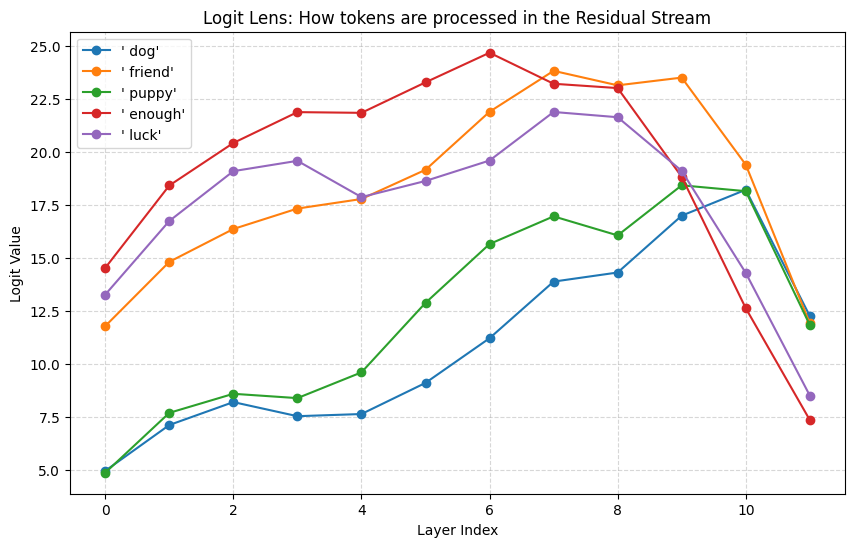

In [19]:
import torch
import matplotlib.pyplot as plt

# Define the candidates we want to track
candidates = [' dog', ' friend', ' puppy', ' enough', ' luck']
candidate_ids = [model.to_single_token(c) for c in candidates]

# Initialize dictionary to track logits across all 12 layers (0 to 11)
layer_logits = {c: [] for c in candidates}
num_layers = model.cfg.n_layers

for l in range(num_layers):
    # Extract residual stream after the current block's processing
    resid_act = clean_cache[f"blocks.{l}.hook_resid_post"][0, -1, :]

    # Project to vocabulary using the final unembedding pipeline (Logit Lens)
    normalized_act = model.ln_final(resid_act)
    logits = torch.matmul(normalized_act, model.W_U)

    # Extract logits for each candidate token
    for char, token_id in zip(candidates, candidate_ids):
        layer_logits[char].append(logits[token_id].item())

# Plot the logit lens trajectory
plt.figure(figsize=(10, 6))
for char in candidates:
    plt.plot(range(num_layers), layer_logits[char], marker='o', label=f"'{char}'")

plt.title("Logit Lens: How tokens are processed in the Residual Stream")
plt.xlabel("Layer Index")
plt.ylabel("Logit Value")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

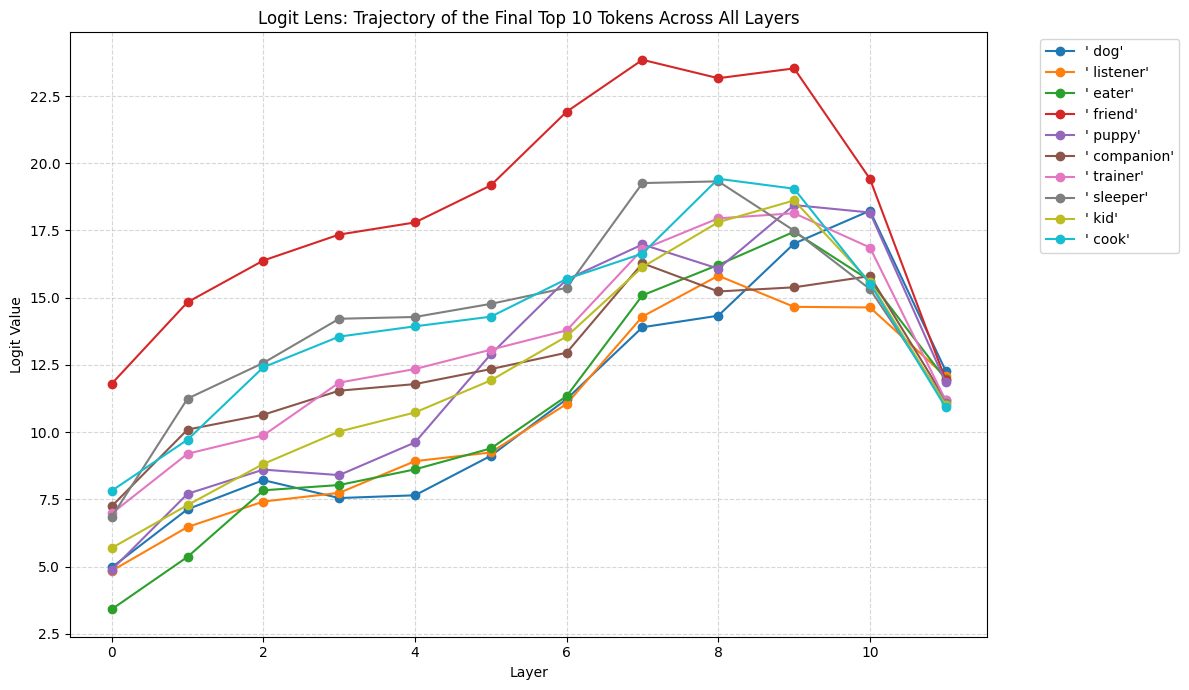

In [20]:
import torch
import matplotlib.pyplot as plt

# 1. Determine the top 10 tokens at the final layer (Layer 11)
final_resid = clean_cache["blocks.11.hook_resid_post"][0, -1, :]
final_normalized = model.ln_final(final_resid)
final_logits = torch.matmul(final_normalized, model.W_U)
top_final_values, top_final_indices = torch.topk(final_logits, k=10)

top_10_tokens = [model.to_string(idx.item()) for idx in top_final_indices]
top_10_ids = top_final_indices.tolist()

# 2. Track these 10 tokens across all 12 layers
num_layers = model.cfg.n_layers
trajectories = {tok: [] for tok in top_10_tokens}

for l in range(num_layers):
    resid_act = clean_cache[f"blocks.{l}.hook_resid_post"][0, -1, :]
    normalized_act = model.ln_final(resid_act)
    logits = torch.matmul(normalized_act, model.W_U)

    for tok_str, tok_id in zip(top_10_tokens, top_10_ids):
        trajectories[tok_str].append(logits[tok_id].item())

# 3. Plot the trajectories
plt.figure(figsize=(12, 7))
for tok_str in top_10_tokens:
    plt.plot(range(num_layers), trajectories[tok_str], marker='o', label=f"{repr(tok_str)}")

plt.title("Logit Lens: Trajectory of the Final Top 10 Tokens Across All Layers")
plt.xlabel("Layer")
plt.ylabel("Logit Value")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

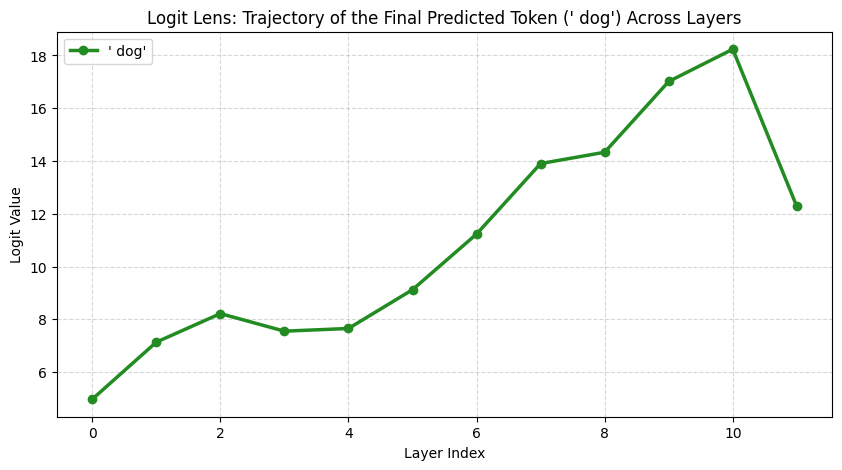

In [21]:
import torch
import matplotlib.pyplot as plt

# 1. Target the final prediction token ' dog'
target_token = ' dog'
target_id = model.to_single_token(target_token)

# 2. Track its logit value across all 12 layers
num_layers = model.cfg.n_layers
trajectory = []

for l in range(num_layers):
    resid_act = clean_cache[f"blocks.{l}.hook_resid_post"][0, -1, :]
    normalized_act = model.ln_final(resid_act)
    logits = torch.matmul(normalized_act, model.W_U)
    trajectory.append(logits[target_id].item())

# 3. Plot the trajectory for ' dog'
plt.figure(figsize=(10, 5))
plt.plot(range(num_layers), trajectory, marker='o', color='forestgreen', linewidth=2.5, label=f"'{target_token}'")

plt.title("Logit Lens: Trajectory of the Final Predicted Token (' dog') Across Layers")
plt.xlabel("Layer Index")
plt.ylabel("Logit Value")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

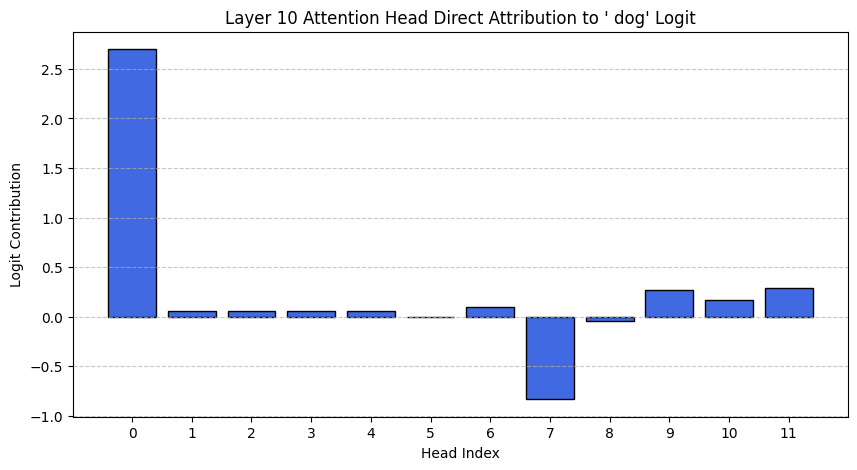

Head 10.0  | Contribution: +2.6979
Head 10.1  | Contribution: +0.0608
Head 10.2  | Contribution: +0.0557
Head 10.3  | Contribution: +0.0549
Head 10.4  | Contribution: +0.0537
Head 10.5  | Contribution: -0.0006
Head 10.6  | Contribution: +0.0984
Head 10.7  | Contribution: -0.8335
Head 10.8  | Contribution: -0.0433
Head 10.9  | Contribution: +0.2674
Head 10.10 | Contribution: +0.1699
Head 10.11 | Contribution: +0.2931


In [26]:
import torch
import matplotlib.pyplot as plt

# 1. Target variables
layer = 10
target_token = ' dog'
target_id = model.to_single_token(target_token)
num_heads = model.cfg.n_heads
d_head = model.cfg.d_head

# 2. Reconstruct the attention head outputs using hook_z and W_O
z = clean_cache[f"blocks.{layer}.attn.hook_z"][0, -1, :, :]
W_O = model.blocks[layer].attn.W_O

# Project each head output: head_output = z_h @ W_O_h
head_outputs = torch.zeros((num_heads, model.cfg.d_model), device=z.device)
for h in range(num_heads):
    head_outputs[h] = torch.matmul(z[h], W_O[h])

# 3. Apply the final layer norm scale manually
final_resid = clean_cache["blocks.11.hook_resid_post"][0, -1, :]
variance = torch.var(final_resid, unbiased=False)
scale = torch.sqrt(variance + model.ln_final.eps)

# Fetch weights from ln_final (which might be named 'w' or 'weight' in different versions)
ln_weight = model.ln_final.w if hasattr(model.ln_final, 'w') else model.ln_final.state_dict().get('weight', 1.0)

# Normalize head outputs and apply the ln_final weight
normalized_head_outputs = (head_outputs / scale) * ln_weight

# Get the unembedding vector for ' dog'
W_U_target = model.W_U[:, target_id]

# Calculate direct logit contribution for each head
contributions = []
for head in range(num_heads):
    attrib = torch.dot(normalized_head_outputs[head], W_U_target).item()
    contributions.append(attrib)

# 4. Plot head contributions
plt.figure(figsize=(10, 5))
plt.bar(range(num_heads), contributions, color='royalblue', edgecolor='black')
plt.title(f"Layer {layer} Attention Head Direct Attribution to '{target_token}' Logit")
plt.xlabel("Head Index")
plt.ylabel("Logit Contribution")
plt.xticks(range(num_heads))
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

# Display the numerical values
for head, val in enumerate(contributions):
    print(f"Head {layer}.{head:<2} | Contribution: {val:+.4f}")

### 📝 Mechanistic Interpretability Summary Notes

#### 1. Residual Stream & The Logit Lens
* **Concept:** The residual stream acts as a shared memory pipeline. Rather than layers completely overwriting previous outputs, they make incremental additions: $x_{l+1} = x_l + \text{Attn}(x_l) + \text{MLP}(x_l)$.
* **Logit Lens:** By applying the final layer normalization (`model.ln_final`) and the unembedding matrix (`model.W_U`) directly to intermediate layers, we can "read" the model's thoughts at each step.
* **Observation:** In the trajectory of `' dog'`, we saw its prediction steadily rise and peak at **Layer 10** (~18.23 logit value) before a slight reduction in Layer 11 as the model calibrated final probabilities.
* **The Top-K vs. Full Trajectory Discrepancy:** Every vocabulary token has a logit value at every layer. At Layer 3, the logit for `' dog'` is ~7.55, which is too low to rank in the top 10 decoded tokens (where the cutoff is >15.0). However, because we explicitly track its token ID, its continuous evolutionary path can still be mapped on the trajectory plots.

#### 2. Layer 10 Attention Head Direct Attribution Analysis
By isolating the direct output of individual attention heads in **Layer 10** at the final token position, we evaluated how much each head writes in the direction of the `' dog'` token:

* **Key Driver (Head 10.0):** Contributed **+2.6979** directly to the `' dog'` logit. This head plays a primary role in routing context representations toward predicting our target noun.
* **Suppressor Head (Head 10.7):** Contributed **-0.8335**. This head tempers the model's confidence in `' dog'`, likely to preserve structural balance or promote alternative candidates (e.g., `' friend'`, which ultimately won at the final layer).
* **Passive Heads:** Most other heads in Layer 10 had contributions close to 0, showing that their attention focus is assigned to tasks other than directly determining the next vocabulary token.